# Step 6 halo and stellar-mass deterministic test

This notebook reads the original Step 6 posterior files, randomly selects 100 samples from each cosmology run, computes the derived halo and stellar-mass quantities in-place, and makes a scatter-style corner plot. It is a lightweight test of `add_step6_halo_stellar_deterministics.py` before running that script on the full posterior.


In [1]:
import os
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")

from pathlib import Path

import corner
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from scipy.optimize import brentq
from scipy.special import hyp2f1
from tqdm.auto import tqdm


In [2]:
PANTHEON_SH0ES_NC = Path(
    "/mnt/lustre/tianli/quasar_hmc/"
    "WFI2033_ss=2_fullconcen_light_multimass_step6_pantheonsh0es_reuse_redwarmup_20260507_14/"
    "WFI2033_all_ss=2_fullconcen_light_multimass_step6_pantheonsh0es_reuse_redwarmup.nc"
)

DESI_PLANCK_NC = Path(
    "/mnt/lustre/tianli/quasar_hmc/"
    "WFI2033_ss=2_fullconcen_light_multimass_step6_desi_planck_20260504_16/"
    "WFI2033_all_ss=2_fullconcen_light_multimass_step6_desi_planck.nc"
)

POST_VARS = [
    "mass_from_light_amp",
    "kappa_s_halo",
    "gammain_halo",
    "Rs_halo",
    "H0_cosmo",
    "omega_m_cosmo",
    "m2l_ratio",
    "m2l_ratio_slope",
]

N_SAMPLE = 100
RNG_SEED = 20260512

Z_LENS = 0.6575
Z_SOURCE = 1.662
DELTA_HALO = 200.0
N_QUAD = 96

C_KM_S = 299792.458
G_PC_KMS2_MSUN = 4.300917270038e-3
ARCSEC_TO_RAD = np.pi / (180.0 * 3600.0)

print("PANTHEON_SH0ES_NC =", PANTHEON_SH0ES_NC)
print("DESI_PLANCK_NC =", DESI_PLANCK_NC)


PANTHEON_SH0ES_NC = /mnt/lustre/tianli/quasar_hmc/WFI2033_ss=2_fullconcen_light_multimass_step6_pantheonsh0es_reuse_redwarmup_20260507_14/WFI2033_all_ss=2_fullconcen_light_multimass_step6_pantheonsh0es_reuse_redwarmup.nc
DESI_PLANCK_NC = /mnt/lustre/tianli/quasar_hmc/WFI2033_ss=2_fullconcen_light_multimass_step6_desi_planck_20260504_16/WFI2033_all_ss=2_fullconcen_light_multimass_step6_desi_planck.nc


In [3]:
def flat_lcdm_comoving_distance_mpc(z, H0, omega_m, n_quad=N_QUAD):
    nodes, weights = np.polynomial.legendre.leggauss(n_quad)
    z_nodes = 0.5 * z * (nodes + 1.0)
    w_nodes = 0.5 * z * weights
    e_z = np.sqrt(omega_m[..., None] * (1.0 + z_nodes) ** 3 + (1.0 - omega_m[..., None]))
    return C_KM_S * np.sum(w_nodes / e_z, axis=-1) / H0


def m_gamma(x, gamma):
    a = 3.0 - gamma
    return x**a / a * hyp2f1(a, a, a + 1.0, -x)


def solve_c200(kappa_s, gamma_in, Rs_arcsec, H0, omega_m):
    dc_lens_mpc = flat_lcdm_comoving_distance_mpc(Z_LENS, H0, omega_m)
    dc_source_mpc = flat_lcdm_comoving_distance_mpc(Z_SOURCE, H0, omega_m)
    d_lens_pc = dc_lens_mpc / (1.0 + Z_LENS) * 1.0e6
    d_source_pc = dc_source_mpc / (1.0 + Z_SOURCE) * 1.0e6
    d_lens_source_pc = (dc_source_mpc - dc_lens_mpc) / (1.0 + Z_SOURCE) * 1.0e6

    sigma_crit = C_KM_S**2 / (4.0 * np.pi * G_PC_KMS2_MSUN) * d_source_pc / (d_lens_pc * d_lens_source_pc)
    arcsec_to_pc = d_lens_pc * ARCSEC_TO_RAD
    Rs_pc = Rs_arcsec * arcsec_to_pc
    rho_s = kappa_s * sigma_crit / Rs_pc
    Hz = H0 * np.sqrt(omega_m * (1.0 + Z_LENS) ** 3 + (1.0 - omega_m))
    rho_crit = 3.0 * (Hz / 1.0e6) ** 2 / (8.0 * np.pi * G_PC_KMS2_MSUN)
    rhs = DELTA_HALO / 3.0 * rho_crit / rho_s

    c200 = np.empty_like(rhs, dtype=np.float64)
    for i in tqdm(range(rhs.size), desc="solving c200"):
        c200[i] = brentq(lambda x: m_gamma(x, gamma_in[i]) / x**3 - rhs[i], 1.0e-2, 1.0e3)

    R200_pc = c200 * Rs_pc
    M200_msun = 4.0 * np.pi / 3.0 * DELTA_HALO * rho_crit * R200_pc**3
    return sigma_crit, arcsec_to_pc, rho_s, rho_crit, R200_pc / 1.0e3, M200_msun, c200


def load_random_original_samples(nc_path, n_sample=100, seed=0):
    post = xr.open_dataset(nc_path, group="posterior", engine="h5netcdf")[POST_VARS].load()
    flat = post.stack(sample=("chain", "draw")).transpose("sample", ...)
    rng = np.random.default_rng(seed)
    sample_index = rng.choice(flat.sizes["sample"], size=n_sample, replace=False)
    return flat.isel(sample=sample_index)


def compute_derived_sample(flat_sample):
    kappa_s = np.asarray(flat_sample["kappa_s_halo"].values, dtype=np.float64)
    gamma_in = np.asarray(flat_sample["gammain_halo"].values, dtype=np.float64)
    Rs_arcsec = np.asarray(flat_sample["Rs_halo"].values, dtype=np.float64)
    H0 = np.asarray(flat_sample["H0_cosmo"].values, dtype=np.float64)
    omega_m = np.asarray(flat_sample["omega_m_cosmo"].values, dtype=np.float64)
    mass_from_light_amp = np.asarray(flat_sample["mass_from_light_amp"].values, dtype=np.float64)

    sigma_crit, arcsec_to_pc, rho_s, rho_crit, R200_kpc, M200_msun, c200 = solve_c200(kappa_s, gamma_in, Rs_arcsec, H0, omega_m)
    stellar_mass_gauss = mass_from_light_amp * (sigma_crit * arcsec_to_pc**2)[:, None]
    total_stellar_mass_msun = np.sum(stellar_mass_gauss, axis=1)

    return {
        "M200_halo_1E12": M200_msun / 1.0e12,
        "c200_halo": c200,
        "R200_halo_kpc": R200_kpc,
        "total_stellar_mass_1E11": total_stellar_mass_msun / 1.0e11,
        "m2l_ratio": np.asarray(flat_sample["m2l_ratio"].values, dtype=float),
        "m2l_ratio_slope": np.asarray(flat_sample["m2l_ratio_slope"].values, dtype=float),
        "stellar_mass_gauss_1E11": stellar_mass_gauss / 1.0e11,
        "sigma_crit_msun_pc2": sigma_crit,
        "arcsec_to_pc": arcsec_to_pc,
        "rho_s_halo_msun_pc3": rho_s,
        "rho_crit_msun_pc3": rho_crit,
    }


def corner_array(derived, var_names):
    return np.column_stack([np.asarray(derived[name], dtype=float).reshape(-1) for name in var_names])


In [4]:
pantheon_flat = load_random_original_samples(PANTHEON_SH0ES_NC, N_SAMPLE, RNG_SEED + 1)
desi_flat = load_random_original_samples(DESI_PLANCK_NC, N_SAMPLE, RNG_SEED + 2)

pantheon_derived = compute_derived_sample(pantheon_flat)
desi_derived = compute_derived_sample(desi_flat)

print("Pantheon+SH0ES medians:")
for name in ["M200_halo_1E12", "c200_halo", "R200_halo_kpc", "total_stellar_mass_1E11"]:
    print(f"  {name}: {np.nanmedian(pantheon_derived[name]):.4g}")

print("DESI+Planck medians:")
for name in ["M200_halo_1E12", "c200_halo", "R200_halo_kpc", "total_stellar_mass_1E11"]:
    print(f"  {name}: {np.nanmedian(desi_derived[name]):.4g}")


solving c200:   0%|          | 0/100 [00:00<?, ?it/s]

solving c200:   0%|          | 0/100 [00:00<?, ?it/s]

Pantheon+SH0ES medians:
  M200_halo_1E12: 5.017
  c200_halo: 4.706
  R200_halo_kpc: 263.8
  total_stellar_mass_1E11: 2.351
DESI+Planck medians:
  M200_halo_1E12: 7.87
  c200_halo: 4.485
  R200_halo_kpc: 327.3
  total_stellar_mass_1E11: 1.955


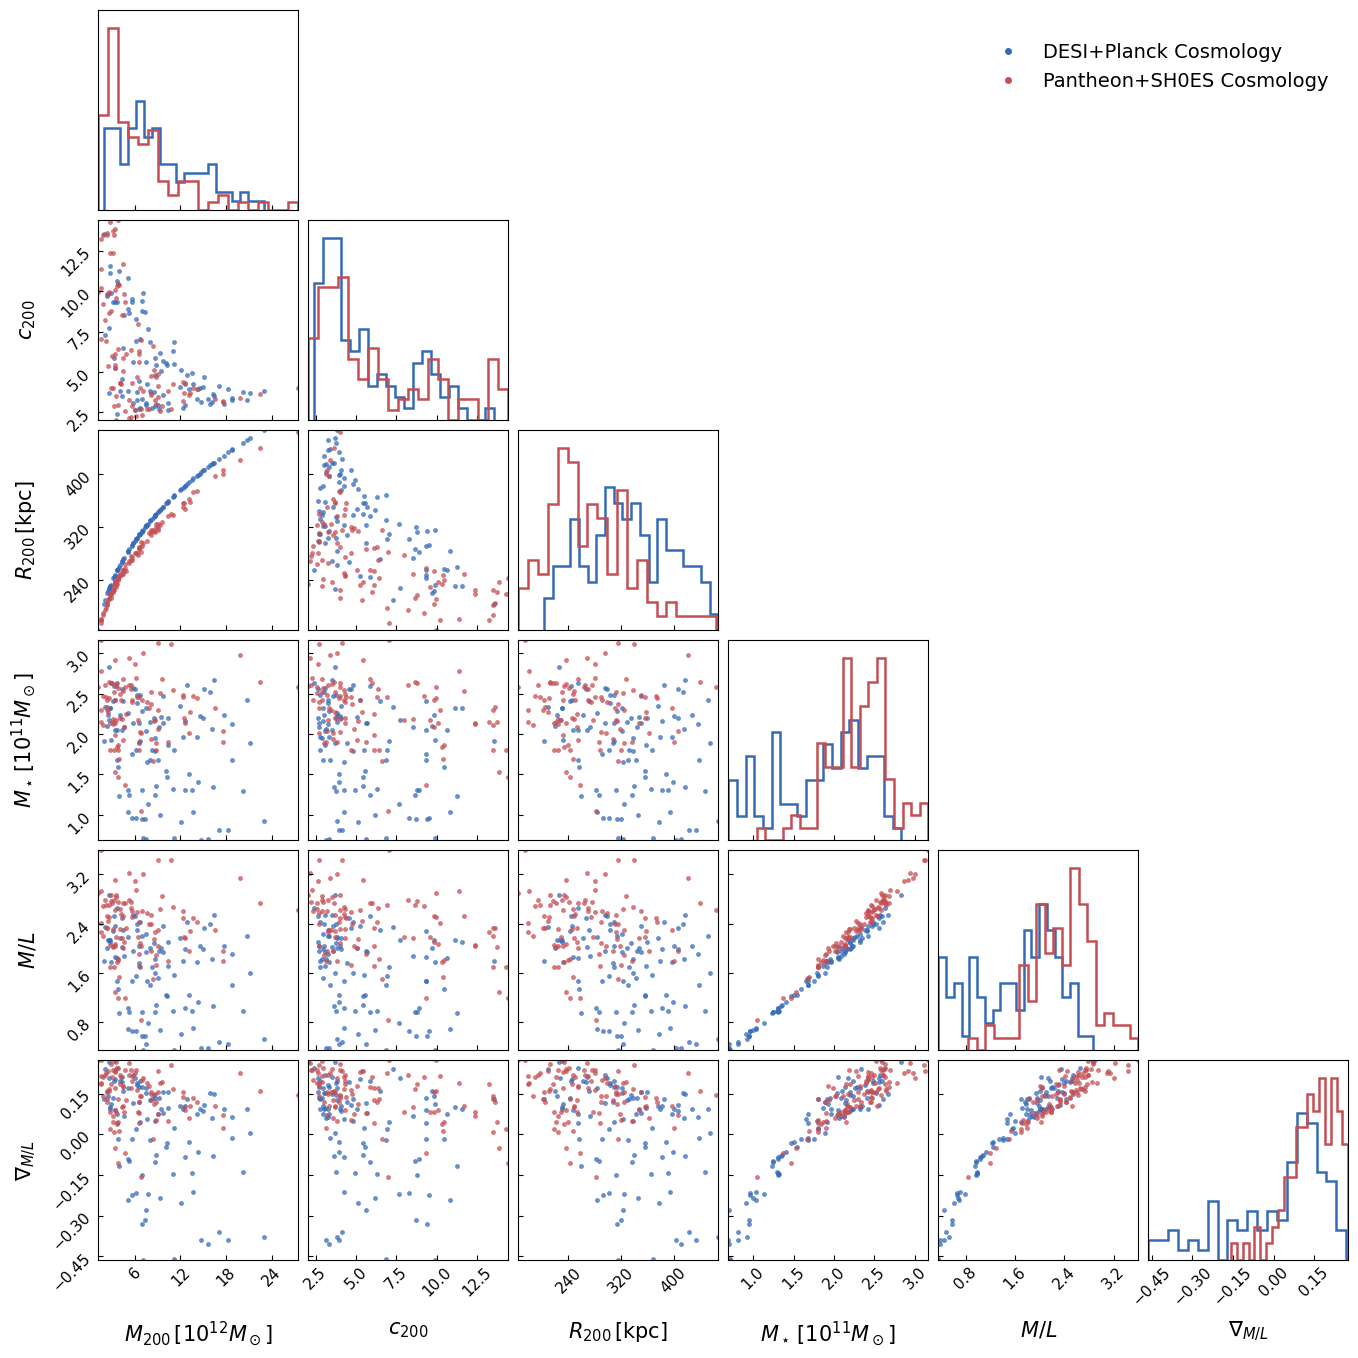

In [5]:
VARS = [
    "M200_halo_1E12",
    "c200_halo",
    "R200_halo_kpc",
    "total_stellar_mass_1E11",
    "m2l_ratio",
    "m2l_ratio_slope",
]

LABELS = [
    r"$M_{200}\,[10^{12}M_\odot]$",
    r"$c_{200}$",
    r"$R_{200}\,[\mathrm{kpc}]$",
    r"$M_\star\,[10^{11}M_\odot]$",
    r"$M/L$",
    r"$\nabla_{M/L}$",
]

desi_sample = corner_array(desi_derived, VARS)
pantheon_sample = corner_array(pantheon_derived, VARS)

fig = corner.corner(
    desi_sample,
    labels=LABELS,
    color="#356ab7",
    plot_datapoints=True,
    plot_density=False,
    plot_contours=False,
    fill_contours=False,
    hist_kwargs={"density": True, "histtype": "step", "linewidth": 1.8},
    data_kwargs={"alpha": 0.75, "ms": 3.5},
    label_kwargs={"fontsize": 15},
)

corner.corner(
    pantheon_sample,
    labels=LABELS,
    fig=fig,
    color="#c44e52",
    plot_datapoints=True,
    plot_density=False,
    plot_contours=False,
    fill_contours=False,
    hist_kwargs={"density": True, "histtype": "step", "linewidth": 1.8},
    data_kwargs={"alpha": 0.75, "ms": 3.5},
)

fig.legend(
    handles=[
        plt.Line2D([], [], color="#356ab7", marker=".", linestyle="None", markersize=8, label="DESI+Planck Cosmology"),
        plt.Line2D([], [], color="#c44e52", marker=".", linestyle="None", markersize=8, label="Pantheon+SH0ES Cosmology"),
    ],
    loc="upper left",
    bbox_to_anchor=(0.70, 0.96),
    frameon=False,
    fontsize=14,
)

for ax in fig.get_axes():
    ax.tick_params(axis="both", which="major", labelsize=11, direction="in")
    ax.tick_params(axis="both", which="minor", direction="in")

plt.savefig("./Paper/step6_derived_halo_stellar_100sample_corner_scatter.pdf", dpi=300, bbox_inches="tight")
plt.show()
